<a href="https://colab.research.google.com/github/orianacuzzi/TripleTen/blob/main/S8_Student_Version_Project_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:

df.head()# mostrar las primeras 5 filas



,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
edad (float64)
nivel_ingreso (float64)
visitas_mes (int64)
compras_mes (int64)
gasto_publicidad_dirigida (float64)
satisfaccion (float64)
ingreso_anual (float64)

La mayoría de estas variables presentan tipos de datos adecuados (int o float).

La columna edad contiene valores continuos representados como float, lo cual es válido aunque podría convertirse a int si se desea mayor consistencia.
nivel_ingreso e ingreso_anual son variables clave para el análisis económico.
satisfaccion se encuentra en una escala de 1 a 5, lo que sugiere una variable ordinal.

En general, no se observan inconsistencias evidentes en los tipos de datos.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium` (int64)
- `abandono`(int64)

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`(object)
- `tipo_dispositivo`(object)
- `region`(object)
- `id_cliente` actúa como identificador único
- `tipo_dispositivo` incluye categorías como móvil, escritorio y tablet.
- `region` contiene valores como norte, sur, este y oeste.
Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
df['edad'] = df['edad'].astype(int)


In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
 # Estadísticas descriptivas de variables numéricas
df.describe()


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — Los valores oscilan entre 18 y 75 años, con una media de 38.26. La distribución parece realista y sin valores atípicos evidentes. No se observan inconsistencias.
- `nivel`_ingreso —Presenta un rango entre 8,000 y 74,790, con una media cercana a 30,000. La dispersión es moderada (std ≈ 9,833), lo que sugiere diversidad en los niveles socioeconómicos, pero dentro de rangos plausibles.
- `visitas_mes` — Varía entre 1 y 25 visitas mensuales, con una media de 10.03. No hay valores extremos preocupantes, aunque el valor máximo podría representar usuarios altamente activos.
- `compras_mes` —Oscila entre 0 y 8 compras, con una media de 1.2. Se observa que el percentil 25 es 0, lo que indica que una proporción relevante de usuarios no realiza compras mensuales.
- `gasto_publicidad_dirigida` —Va de 0 a 75.51, con media de 20.15. La presencia de valores en 0 indica usuarios sin inversión publicitaria, lo cual es consistente con estrategias de segmentación.
- `satisfaccion` —Se encuentra en el rango esperado de 1 a 5, con media de 3.6. La distribución parece relativamente centrada, sin sesgos extremos.
- `miembro_premium` —Variable binaria con media de 0.139, lo que indica que aproximadamente el 13.9% de los clientes son premium. Existe un claro desbalance hacia usuarios no premium.
- `abandono` —Con media de 0.151, alrededor del 15.1% de los clientes han abandonado la plataforma. También presenta desbalance, lo cual es relevante para futuros modelos.
- `ingreso_anual` —Variable objetivo con valores entre 0 y 244.69 y una media de 36.59. Se observa que el percentil 25 es 0, lo que indica que una proporción significativa de clientes no genera ingresos. Esto sugiere una posible distribución sesgada y presencia de muchos valores cero.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ['miembro_premium', 'abandono']

for columna in columnas_binarias:
    valores_unicos = df[columna].unique()
    print(f"{columna}: {valores_unicos} (Total: {len(valores_unicos)} valores)")

miembro_premium: [0 1] (Total: 2 valores)
abandono: [0 1] (Total: 2 valores)


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` —
La variable contiene exactamente dos valores posibles (0 y 1), lo que confirma que está correctamente codificada como binaria. Se observa que representa una minoría de clientes premium, lo que sugiere un claro desbalance hacia la categoría 0 (no premium). Este detalle es importante porque puede influir en análisis posteriores y en modelos predictivos.

- `abandono` —
También presenta dos valores posibles (0 y 1), sin inconsistencias ni categorías adicionales. La distribución indica que la mayoría de los clientes no han abandonado la plataforma (clase 0 dominante), mientras que aproximadamente un 15% corresponde a clientes que sí abandonaron. Este desbalance es relevante, ya que puede afectar la detección de patrones relacionados con la pérdida de clientes.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
categorical_cols = ['id_cliente', 'tipo_dispositivo', 'region']
df[categorical_cols].nunique()

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
for col in categorical_cols:
    print(f"\nDistribución de {col}")
    print(df[col].value_counts())


Distribución de id_cliente
CL-113270    1
CL-113330    1
CL-102194    1
CL-111782    1
CL-112002    1
            ..
CL-111962    1
CL-110885    1
CL-110022    1
CL-114316    1
CL-103063    1
Name: id_cliente, Length: 15000, dtype: int64

Distribución de tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Se observan tres categorías: móvil, escritorio y tablet. La distribución está claramente desbalanceada, con predominio de usuarios móviles (9818 registros), seguido de escritorio (3720) y tablet (1462). Este patrón sugiere que la mayoría de los usuarios accede a la plataforma desde dispositivos móviles, lo cual puede ser relevante para decisiones de producto o marketing.
- `region` —La variable presenta cuatro categorías: norte, oeste, sur y este. La distribución es relativamente equilibrada, aunque se observa una ligera mayor concentración en la región norte (4395 registros) y menor representación en la región este (3069 registros). No se detectan inconsistencias ni categorías inesperadas.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

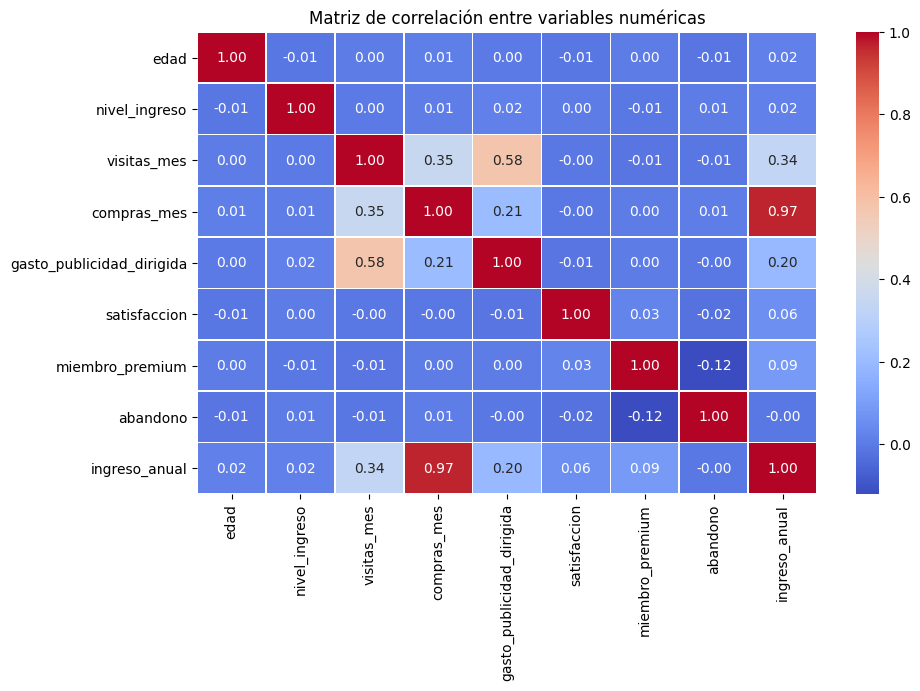

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo variables numéricas
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calcular matriz de correlación
corr = numeric_df.corr()

# Crear heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa que la mayoría de las variables presentan correlaciones bajas entre sí, lo que indica que no existen relaciones lineales fuertes generalizadas en el conjunto de datos. Sin embargo, destacan algunas relaciones moderadas entre variables relacionadas con el comportamiento del usuario.

En particular, visitas_mes y compras_mes muestran una correlación positiva moderada (0.35), lo que indica que ambas variables tienden a aumentar de forma conjunta en algunos casos. También se observa una correlación moderada entre visitas_mes y gasto_publicidad_dirigida (0.58), lo que sugiere una asociación entre estas variables.


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación muy alta con compras_mes (0.97), lo que indica una fuerte relación lineal entre ambas variables. También se observa una correlación moderada con visitas_mes (0.34) y una relación más débil con gasto_publicidad_dirigida (0.20).

El resto de variables, como edad, nivel_ingreso, satisfaccion y las variables binarias (miembro_premium y abandono), muestran correlaciones cercanas a cero con la variable objetivo, lo que indica ausencia de relaciones lineales relevantes en estos casos.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.
  - Sí, en este caso sí es recomendable incluir un scatterplot, pero no uno “general” de todo el dataset, sino enfocado en las variables con mayor correlación, porque el heatmap ya sugiere una relación muy fuerte entre algunas variables.
  - El heatmap mostró una correlación muy alta entre compras_mes e ingreso_anual (0.97). Esto hace útil visualizar la relación con un scatterplot para entender la forma de esa asociación y detectar posibles patrones, dispersión o agrupamientos.

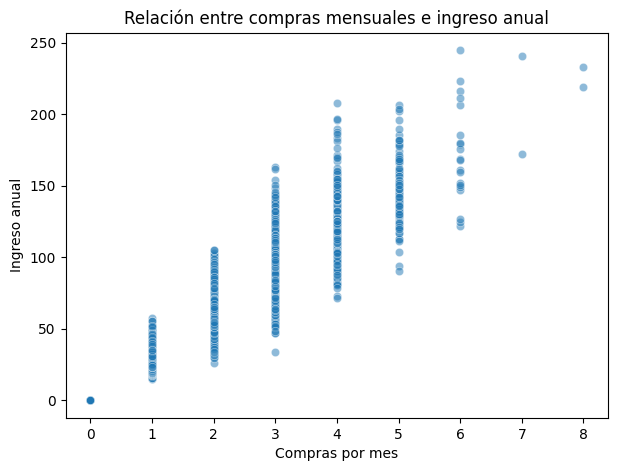

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', alpha=0.5)

plt.title("Relación entre compras mensuales e ingreso anual")
plt.xlabel("Compras por mes")
plt.ylabel("Ingreso anual")
plt.show()

### Scatterplot para pares clave

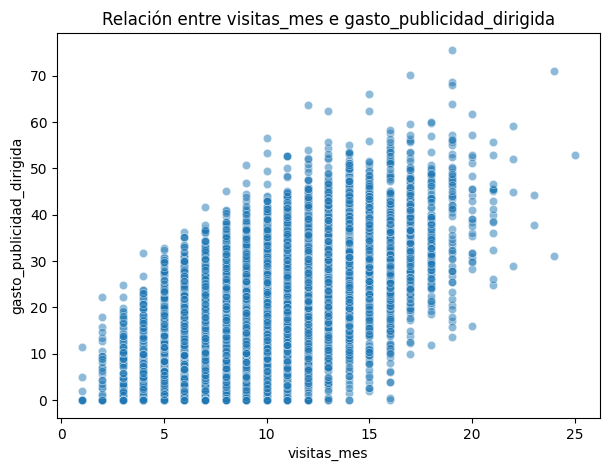

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='visitas_mes', y='gasto_publicidad_dirigida', alpha=0.5)

plt.title("Relación entre visitas_mes e gasto_publicidad_dirigida")
plt.xlabel("visitas_mes")
plt.ylabel("gasto_publicidad_dirigida")
plt.show()

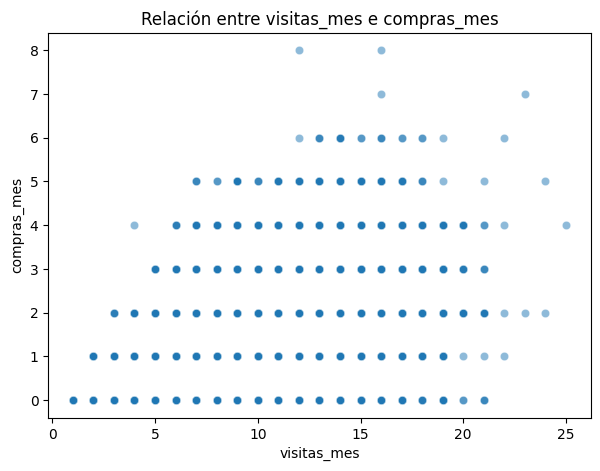

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='visitas_mes', y='compras_mes', alpha=0.5)

plt.title("Relación entre visitas_mes e compras_mes")
plt.xlabel("visitas_mes")
plt.ylabel("compras_mes")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


- `compras_mes vs ingreso_anual`
- Dirección: Positiva muy fuerte
- Dispersión: Baja
- Qué se ve: Los puntos siguen casi una línea recta ascendente → relación casi lineal perfecta
- Outliers: No se observan outliers claros; algunos valores altos pero consistentes con la tendencia
- Colinealidad: Muy alta → estas variables están fuertemente relacionadas y pueden ser redundantes en modelos
- `visitas_mes vs gasto_publicidad_dirigida`
- Dirección: Positiva
- Dispersión: Media
- Qué se ve: Tendencia ascendente clara, pero con bastante variabilidad vertical
- Outliers: No evidentes; la nube es amplia pero coherente
- Interpretación: La publicidad influye en visitas, pero no es el único factor
- `visitas_mes vs compras_mes`
- Dirección: Positiva
- Dispersión: Media-alta
- Qué se ve: Patrón escalonado (valores discretos), con tendencia creciente pero bastante dispersión
- Outliers: Algunos puntos altos (muchas compras con visitas moderadas), pero no extremos
- Interpretación: Más visitas tienden a generar más compras, aunque con variabilidad significativa

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
corr_pearson = df[['compras_mes', 'ingreso_anual',
                   'visitas_mes', 'gasto_publicidad_dirigida']].corr(method='pearson')

print(corr_pearson)


                           compras_mes  ingreso_anual  visitas_mes  \
compras_mes                   1.000000       0.967149     0.353844   
ingreso_anual                 0.967149       1.000000     0.337147   
visitas_mes                   0.353844       0.337147     1.000000   
gasto_publicidad_dirigida     0.207528       0.197483     0.578947   

                           gasto_publicidad_dirigida  
compras_mes                                 0.207528  
ingreso_anual                               0.197483  
visitas_mes                                 0.578947  
gasto_publicidad_dirigida                   1.000000  


In [ ]:
# Calcular correlación entre variables relevantes
corr_spearman = df[['compras_mes', 'ingreso_anual',
                    'visitas_mes', 'gasto_publicidad_dirigida']].corr(method='spearman')

print(corr_spearman)

                           compras_mes  ingreso_anual  visitas_mes  \
compras_mes                   1.000000       0.967482     0.332943   
ingreso_anual                 0.967482       1.000000     0.320954   
visitas_mes                   0.332943       0.320954     1.000000   
gasto_publicidad_dirigida     0.192511       0.184999     0.559267   

                           gasto_publicidad_dirigida  
compras_mes                                 0.192511  
ingreso_anual                               0.184999  
visitas_mes                                 0.559267  
gasto_publicidad_dirigida                   1.000000  


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.

`compras_mes vs ingreso_anual`
- Dirección: Positiva
- Magnitud: Muy fuerte (Pearson ≈ 0.97 | Spearman ≈ 0.97)
- Interpretación: Existe una relación casi perfecta entre ambas variables
 - Colinealidad: Muy alta → indican redundancia; incluir ambas en un modelo puede generar problemas

`visitas_mes vs compras_mes`
- Dirección: Positiva
- Magnitud: Moderada (Pearson ≈ 0.35 | Spearman ≈ 0.33)
- Interpretación: A mayor número de visitas, tienden a aumentar las compras, pero con variabilidad

`visitas_mes vs ingreso_anual`
- Dirección: Positiva
- Magnitud: Moderada-baja (Pearson ≈ 0.34 | Spearman ≈ 0.32)
- Interpretación: Relación indirecta; el ingreso depende más directamente de las compras

`visitas_mes vs gasto_publicidad_dirigida`
- Dirección: Positiva
- Magnitud: Moderada-alta (Pearson ≈ 0.58 | Spearman ≈ 0.56)
- Interpretación: La publicidad dirigida tiene un impacto relevante en el tráfico (visitas)

 Conclusión general
- Las correlaciones de Pearson y Spearman son muy similares, lo que indica relaciones mayormente lineales y monotónicas.
- La relación más relevante es:
 - compras_mes ↔ ingreso_anual (colinealidad fuerte)
- La publicidad impacta principalmente en visitas, y estas a su vez en compras, sugiriendo un efecto en cadena.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr
import pandas as pd

# Variables binarias y numéricas
binarias = ['miembro_premium', 'abandono']
numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes',
             'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

# Calcular correlaciones
resultados = []

for b in binarias:
    for n in numericas:
        corr, pval = pointbiserialr(df[b], df[n])
        resultados.append({
            'Variable_binaria': b,
            'Variable_numerica': n,
            'Correlacion': round(corr, 4),
            'p_value': round(pval, 4)
        })

# Convertir a DataFrame
df_pb = pd.DataFrame(resultados)

# Ordenar por magnitud de correlación
df_pb = df_pb.sort_values(by='Correlacion', key=abs, ascending=False)

print(df_pb)

   Variable_binaria          Variable_numerica  Correlacion  p_value
6   miembro_premium              ingreso_anual       0.0931   0.0000
5   miembro_premium               satisfaccion       0.0257   0.0016
12         abandono               satisfaccion      -0.0238   0.0035
2   miembro_premium                visitas_mes      -0.0127   0.1211
7          abandono                       edad      -0.0115   0.1590
9          abandono                visitas_mes      -0.0089   0.2734
10         abandono                compras_mes       0.0083   0.3099
8          abandono              nivel_ingreso       0.0059   0.4722
1   miembro_premium              nivel_ingreso      -0.0056   0.4930
0   miembro_premium                       edad       0.0046   0.5728
11         abandono  gasto_publicidad_dirigida      -0.0046   0.5744
3   miembro_premium                compras_mes       0.0034   0.6744
13         abandono              ingreso_anual      -0.0028   0.7295
4   miembro_premium  gasto_publici

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

- **miembro_premium vs variables numéricas**
- `ingreso_anual`
- Dirección: Positiva
- Magnitud: Baja (0.0931)
- Los clientes premium tienden a generar ligeramente más ingresos
- `satisfaccion`
- Dirección: Positiva
- Magnitud: Muy baja (0.0257)
- Ligera tendencia a mayor satisfacción
- `visitas_mes`
- Dirección: Negativa
- Magnitud: Muy baja (-0.0127)
-  Relación prácticamente nula
- `edad, nivel_ingreso, compras_mes, gasto_publicidad_dirigida`
- Dirección: Mixta
- Magnitud: Muy baja o nula
- Sin relación relevante
- **abandono vs variables numéricas**
- `satisfaccion`
- Dirección: Negativa
- Magnitud: Muy baja (-0.0238)
- Menor satisfacción se asocia ligeramente con mayor abandono
- `edad, visitas_mes`
- Dirección: Negativa
- Magnitud: Muy baja
- Relación casi inexistente
- `compras_mes, nivel_ingreso`
- Dirección: Positiva
- Magnitud: Muy baja
- Sin impacto relevante
- `ingreso_anual, gasto_publicidad_dirigida`
- Dirección: Negativa
- Magnitud: Nula
- No hay relación
- **Conclusión general**
Todas las correlaciones presentan magnitud muy baja (< 0.1)
Las relaciones observadas son débiles y poco relevantes a nivel práctico
No hay patrones claros que indiquen una fuerte asociación entre variables binarias y numéricas

### V de Cramér

In [ ]:

# Función para calcular V de Cramér
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    # Tabla de contingencia
    contingency_table = pd.crosstab(x, y)

    # Chi-cuadrado
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()

    # Dimensiones
    r, k = contingency_table.shape

    # Corrección de V de Cramér
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


In [ ]:

# Aplicar V de Cramér en variables relevantes
categoricas = ['miembro_premium', 'abandono', 'tipo_dispositivo', 'region']

resultados = []

for i in range(len(categoricas)):
    for j in range(i+1, len(categoricas)):
        v = cramers_v(df[categoricas[i]], df[categoricas[j]])
        resultados.append({
            "Variable_1": categoricas[i],
            "Variable_2": categoricas[j],
            "V_de_Cramer": round(v, 4)
        })

df_cramer = pd.DataFrame(resultados).sort_values(by="V_de_Cramer", ascending=False)

print(df_cramer)

         Variable_1        Variable_2  V_de_Cramer
0   miembro_premium          abandono       0.1199
1   miembro_premium  tipo_dispositivo       0.0160
4          abandono            region       0.0062
2   miembro_premium            region       0.0000
3          abandono  tipo_dispositivo       0.0000
5  tipo_dispositivo            region       0.0000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér

- **miembro_premium vs abandono**
- Valor: 0.1199
- Magnitud: Débil
- Interpretación: Existe una ligera asociación entre ser cliente premium y el abandono, pero la relación es pequeña.
- Qué se observa: No hay una dependencia fuerte entre ambos grupos, aunque podría existir una leve tendencia a menor abandono en ciertos segmentos.
- **miembro_premium vs tipo_dispositivo**
- Valor: 0.0160
- Magnitud: Muy débil (casi nula)
- Interpretación: El tipo de dispositivo no está relacionado con ser premium.
- Qué se observa: Los usuarios premium y no premium se distribuyen de forma muy similar entre dispositivos.
- **abandono vs region**
- Valor: 0.0062
- Magnitud: Nula
- Interpretación: La región no influye en el abandono.
- Qué se observa: El comportamiento de abandono es homogéneo entre regiones.
- **miembro_premium vs region**
- Valor: 0.0000
- Magnitud: Nula
- Interpretación: No existe relación entre región y membresía premium.
- **abandono vs tipo_dispositivo**
- Valor: 0.0000
- Magnitud: Nula
- Interpretación: El dispositivo no afecta el abandono.
- **tipo_dispositivo vs region**
- Valor: 0.0000
- Magnitud: Nula
- Interpretación: No hay relación entre tipo de dispositivo y región.
- **Conclusión general**
- La mayoría de las asociaciones son nulas o extremadamente débiles
- La única relación relevante (aunque débil) es:
- miembro_premium ↔ abandono (0.1199)
- No se observa estructura fuerte entre variables categóricas
- Esto sugiere que las variables categóricas del dataset son bastante independientes entre si

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio


✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 —

**Hallazgo 1: Relación entre compras mensuales e ingreso anual**
📉 Evidencia visual

Los scatterplots muestran una relación casi lineal ascendente entre compras_mes e ingreso_anual, con muy poca dispersión.

**Evidencia numérica**
- Pearson: ≈ 0.967
- Spearman: ≈ 0.967
- Interpretación (no causal)

Existe una asociación extremadamente fuerte entre ambas variables, lo que indica que tienden a moverse conjuntamente.
No podemos afirmar que aumentar las compras cause directamente un aumento del ingreso anual.

**Implicación de negocio**

Existe riesgo de colinealidad, por lo que en modelos predictivos no deberían incluirse ambas variables simultáneamente. También sugiere que las compras son un excelente indicador del valor del cliente.

**Hallazgo 2: Relación entre visitas y compras**
📉 Evidencia visual

Los scatterplots muestran una tendencia positiva con dispersión moderada.

**Evidencia numérica**
- Pearson: ≈ 0.35
- Spearman: ≈ 0.33
- Interpretación

Más visitas tienden a asociarse con más compras, aunque la relación no es fuerte.

No podemos afirmar que aumentar visitas automáticamente genere más compras.

**Implicación de negocio**

Incrementar tráfico puede ser útil, pero no garantiza conversión; se necesita optimización de experiencia o conversión.


**Hallazgo 3: Impacto de publicidad en visitas**
📉 Evidencia visual

Relación positiva moderada en los scatterplots.

**Evidencia numérica**
- Pearson: ≈ 0.58
- Spearman: ≈ 0.56
- Interpretación

El gasto en publicidad dirigida se asocia con mayor número de visitas.

No podemos afirmar que toda la mejora en visitas se deba exclusivamente a la publicidad.

**Implicación de negocio**

La inversión en marketing parece efectiva para aumentar tráfico, pero debe complementarse con estrategias de conversión.

**Hallazgo 4: Relación entre membresía premium y variables numéricas**
📉 Evidencia visual

No se observan diferencias claras en distribuciones.

**Evidencia numérica**
- Correlaciones punto-biserial: todas < 0.10
- Interpretación

Ser cliente premium no está fuertemente asociado a variables como ingresos, compras o visitas.
No podemos afirmar que los clientes premium tengan comportamientos significativamente diferentes en estas variables.

**Implicación de negocio**

El programa premium podría necesitar redefinición o segmentación más efectiva.


**Hallazgo 5: Abandono (churn) y variables del cliente**
📉 Evidencia visual

No se observan patrones claros en scatterplots ni en distribuciones.

**Evidencia numérica**
- Punto-biserial: valores cercanos a 0
- V de Cramér: máximo ≈ 0.12 (débil)
- Interpretación

El abandono no está fuertemente explicado por variables individuales del dataset.

No podemos afirmar que ninguna variable por sí sola determine el abandono.

**Implicación de negocio**

El churn probablemente depende de una combinación de factores o variables no incluidas (ej: experiencia, soporte, competencia).


**Hallazgo 6: Relaciones entre variables categóricas**
📉 Evidencia visual

No disponible (análisis basado en tablas de contingencia).

**Evidencia numérica**
- V de Cramér ≈ 0 en la mayoría de pares
- Interpretación

Las variables categóricas son prácticamente independientes entre sí.
No podemos afirmar que región o dispositivo influyan en el comportamiento del cliente.

**Implicación de negocio**

La segmentación por región o dispositivo no aporta valor predictivo en este dataset.

### Hallazgo 2 —

**Evidencia visual:**   
**Evidencia numérica:**

**Interpretación**  


**No podemos afirmar**  


**Implicación de negocio**  


## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

📌 6.1. Limitaciones
⚠️ Correlación ≠ causalidad

Los resultados obtenidos (Pearson, Spearman, punto-biserial y V de Cramér) únicamente muestran asociaciones estadísticas entre variables, pero no permiten establecer relaciones causales.

Esto significa que:

- No podemos afirmar que una variable cause el cambio en otra.
- Las relaciones pueden estar influenciadas por variables no observadas (confusores).
- Algunas correlaciones pueden ser indirectas o espurias.
**Otras limitaciones del análisis**
  
- Las relaciones detectadas son principalmente lineales o monotónicas, por lo que patrones no lineales complejos pueden no haberse capturado completamente.
- Variables categóricas muestran baja variabilidad explicativa, lo que limita su utilidad individual.
- Posible colinealidad fuerte entre variables como compras_mes e ingreso_anual, lo que puede afectar modelos predictivos.
- El análisis es univariado o bivariado, no captura interacciones múltiples entre variables.
-
**6.2. Próximos pasos**

Para profundizar el análisis y obtener mayor valor predictivo para el negocio, se recomienda:

📊 1. Hacer análisis por grupos (segmentación simple)
Comparar clientes:
Premium vs no premium
Abandono vs no abandono
Objetivo: ver diferencias claras en promedios
Ejemplo:
¿Quién compra más?
¿Quién tiene mayor satisfacción?
📊 2. Crear gráficos más explicativos
Boxplots para comparar grupos
Histogramas para ver distribución de variables
Barras para variables categóricas

👉 Objetivo: comunicar mejor los resultados al negocio

📊 3. Analizar variables una por una (análisis univariado)
Revisar:
media
mediana
valores extremos
Objetivo: entender cada variable antes de modelar
📊 4. Detectar y tratar outliers
Identificar valores muy altos o bajos
Decidir si:
se eliminan
se mantienen
se transforman

👉 Importante antes de cualquier modelo

📊 5. Revisar datos faltantes
Ver si hay valores nulos
Decidir:
eliminar filas
imputar valores
📊 6. Crear comparaciones simples de negocio
Ejemplos:
¿Los premium abandonan menos?
¿Los que compran más son más satisfechos?
¿Qué región tiene más clientes activos?

👉 Esto traduce datos a insights de negocio

📊 7. Ordenar variables por importancia visual
Usar:
correlaciones
gráficos de barras
Objetivo: identificar variables más relevantes sin modelos complejos
🧠 Resumen simple

El siguiente paso no es modelar todavía, sino:
👉 entender mejor los datos
👉 compararlos por grupos
👉 visualizar patrones claros
👉 limpiar inconsistencia